## Custom Dataset Generator

In [1]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(42)

def generate_students(n=200, seed=42):
 	rng = np.random.default_rng(seed)
 	hours_studied = rng.normal(5, 2, n).clip(1, 10)
 	marks = (hours_studied * rng.uniform(8, 12, n) + rng.normal(0, 5, n)).clip(30, 100)
 	gender = rng.choice(['Male', 'Female'], n)
 	subject = rng.choice(['Math', 'Science', 'English', 'History'], n)
 	study_method = rng.choice(['Solo', 'Group'], n, p=[0.6, 0.4])
 	attempts = rng.integers(1, 4, n)
 	return pd.DataFrame({
     	'hours_studied': hours_studied.round(2),
     	'marks': marks.round(2),
     	'gender': gender,
     	'subject': subject,
     	'study_method': study_method,
     	'attempts': attempts
 	})

def generate_daily_sales(n=60, seed=42):
 	rng = np.random.default_rng(seed)
 	base = pd.date_range(start='2024-01-01', periods=n, freq='D')
 	trend = np.linspace(50, 80, n)
 	season = 8 * np.sin(np.linspace(0, 3*np.pi, n))
 	noise = rng.normal(0, 3, n)
 	sales = (trend + season + noise).round(2)
 	return pd.DataFrame({'date': base, 'sales': sales})

# Example usage
students = generate_students(220)
sales = generate_daily_sales(90)

In [4]:
print(students)
print(sales)

     hours_studied  marks  gender  subject study_method  attempts
0             5.61  54.04    Male  English         Solo         2
1             2.92  30.00  Female  Science         Solo         2
2             6.50  70.46  Female  History        Group         3
3             6.88  52.76  Female  English        Group         3
4             1.10  30.00  Female  History         Solo         1
..             ...    ...     ...      ...          ...       ...
215           7.01  70.66  Female  English         Solo         1
216           6.08  67.32    Male     Math        Group         2
217           7.67  65.64    Male  Science         Solo         1
218           4.69  41.90    Male     Math         Solo         1
219           3.61  42.19  Female  History         Solo         1

[220 rows x 6 columns]
         date  sales
0  2024-01-01  50.91
1  2024-01-02  48.06
2  2024-01-03  54.61
3  2024-01-04  56.33
4  2024-01-05  48.78
..        ...    ...
85 2024-03-26  83.40
86 2024-03-27  8

### Using sales, draw a lineplot of date vs sales.

<Axes: xlabel='date', ylabel='sales'>

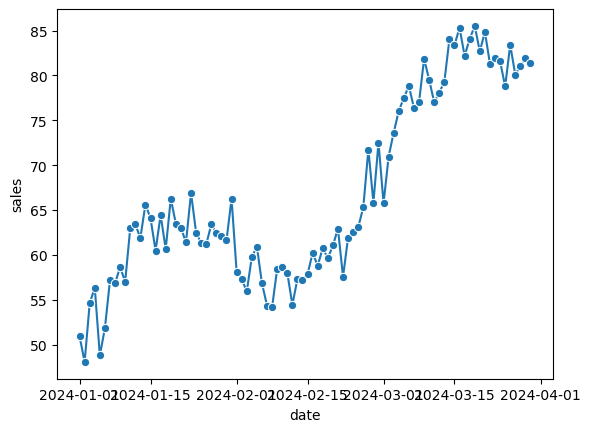

In [10]:
import seaborn as sns
import plotly.express as px

sns.lineplot(data=sales, x='date', y='sales',marker='o')

From students, plot hours_studied vs marks and color by gender.

<Axes: xlabel='hours_studied', ylabel='marks'>

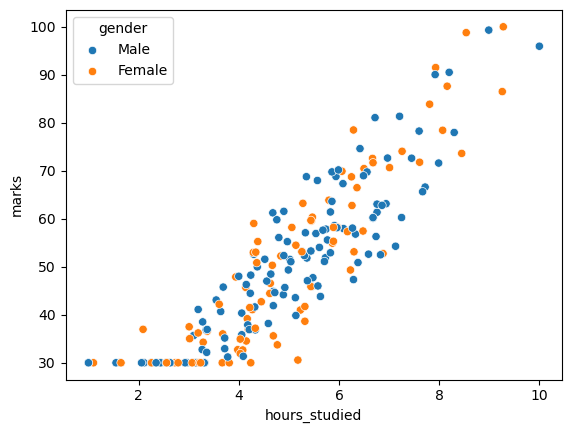

In [11]:
sns.scatterplot(data=students, x='hours_studied', y='marks', hue='gender')

Create a grid of scatterplots (hours_studied vs marks) faceted by subject.

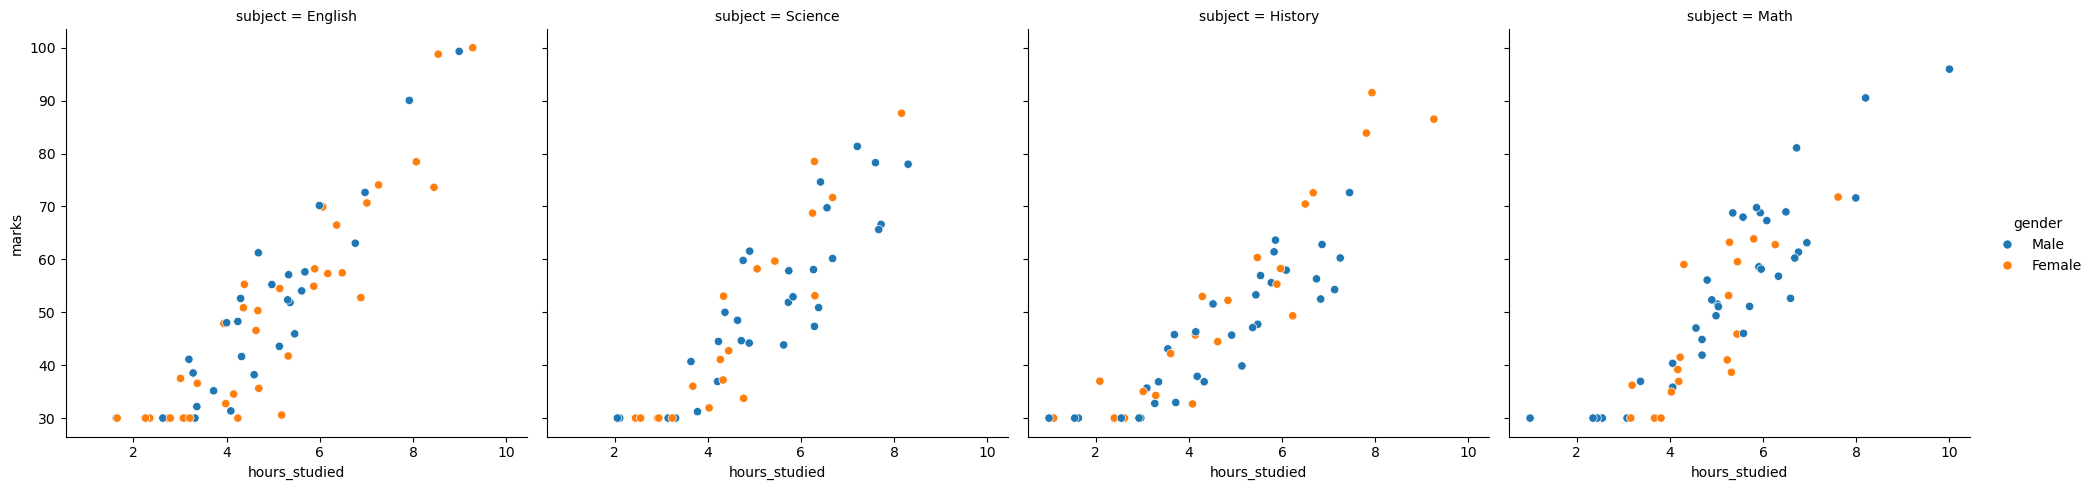

In [13]:
sns.relplot(kind='scatter', data=students, x='hours_studied', y='marks', hue='gender',col='subject')

Plot a histogram of marks with a KDE overlay.

<Axes: xlabel='marks', ylabel='Count'>

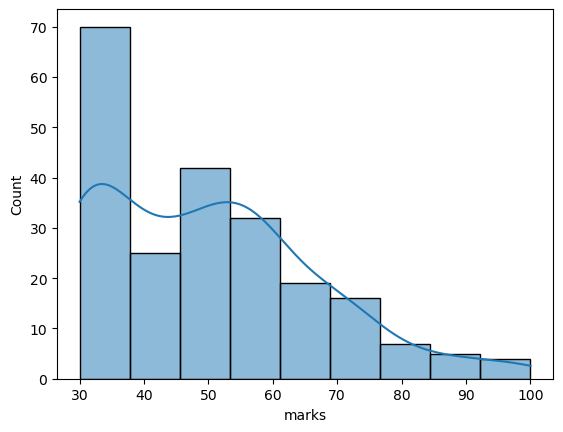

In [14]:
sns.histplot(data=students, x='marks',kde=True)

Show the KDE curve for hours_studied.

<Axes: xlabel='hours_studied', ylabel='Density'>

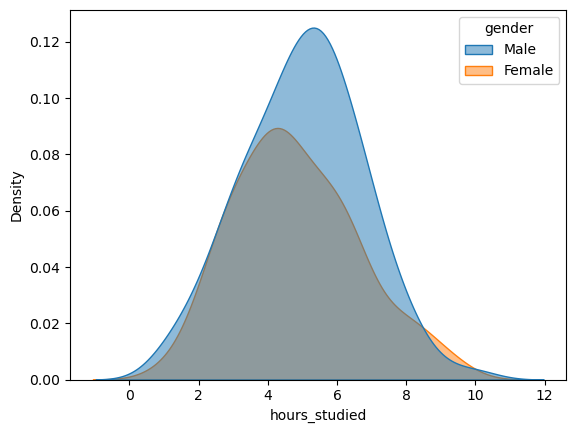

In [16]:
sns.kdeplot(data=students, x='hours_studied', hue='gender',fill=True, alpha=0.5)

Display the count of records per subject.

<Axes: xlabel='subject', ylabel='count'>

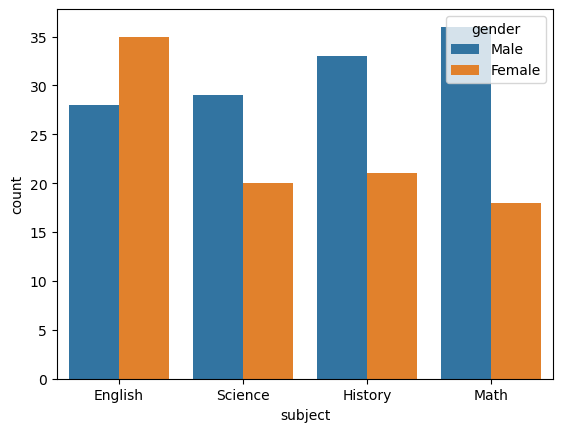

In [18]:
sns.countplot(data=students, x='subject',hue='gender')

Draw a regression line for hours_studied and marks

<Axes: xlabel='hours_studied', ylabel='marks'>

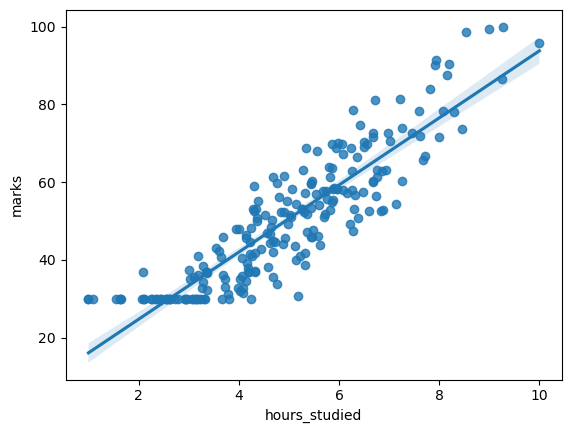

In [20]:
sns.regplot(data=students, x='hours_studied', y='marks')

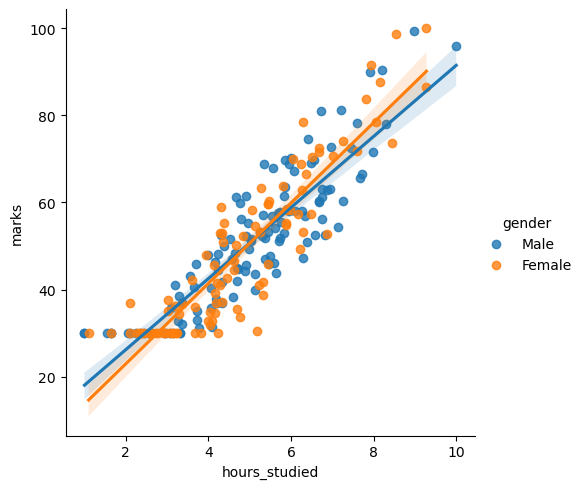

In [22]:
sns.lmplot(data=students, x='hours_studied', y='marks', hue='gender')

Create a pairplot and a jointplot for students' dataset.

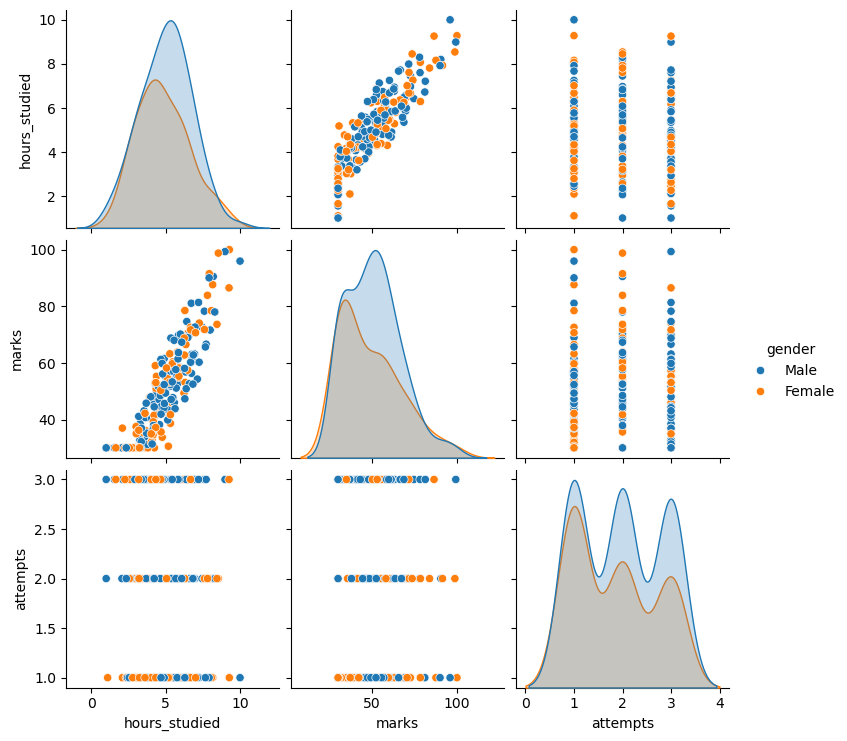

In [23]:
sns.pairplot(data=students, hue='gender')

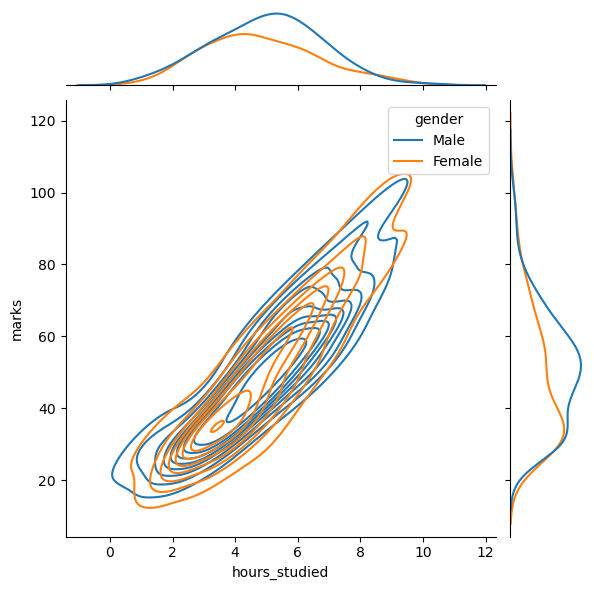

In [27]:
sns.jointplot(data=students, x='hours_studied', y='marks', kind='kde', hue='gender')

Make a scatter plot of hours_studied vs marks using Plotly, colored by gender.

In [28]:
img=px.scatter(students, x='hours_studied', y='marks', color='gender')
img.show()

Draw a line chart of sales over date and a histogram of marks using Plotly.

In [31]:
img = px.line(sales, x='date', y='sales',markers='o')
img.show()

In [35]:
img = px.histogram(students, x='marks', nbins=10, color='gender')
img.show()